In [10]:
import pandas as pd
df=pd.read_csv("spam.csv")
df.head()
df.shape

(5572, 2)

In [4]:
df['Category'].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(df.Message,df.Category,test_size=0.2,random_state=5)

In [6]:
X_train

1658    S:-)if we have one good partnership going we w...
1509    Sounds like something that someone testing me ...
3266    44 7732584351, Do you want a New Nokia 3510i c...
5199           Ugh my leg hurts. Musta overdid it on mon.
3217    URGENT! We are trying to contact U. Todays dra...
                              ...                        
3046    Hello, yeah i've just got out of the bath and ...
1725              There bold 2  &lt;#&gt; . Is that yours
4079                  Gam gone after outstanding innings.
2254                         Lol enjoy role playing much?
2915    Sorry! U can not unsubscribe yet. THE MOB offe...
Name: Message, Length: 4457, dtype: object

In [7]:
X_test

2095    PRIVATE! Your 2004 Account Statement for 07742...
5343    No go. No openings for that room 'til after th...
564     GENT! We are trying to contact you. Last weeke...
3849    Can you plz tell me the ans. BSLVYL sent via f...
3317    I know girls always safe and selfish know i go...
                              ...                        
3473    I think I‘m waiting for the same bus! Inform m...
884                           Dude we should go sup again
5006    Guess which pub im in? Im as happy as a pig in...
3397    URGENT! Your Mobile number has been awarded wi...
1309       I jokin oni lar.. Ü busy then i wun disturb ü.
Name: Message, Length: 1115, dtype: object

In [8]:
y_train

1658     ham
1509     ham
3266    spam
5199     ham
3217    spam
        ... 
3046     ham
1725     ham
4079     ham
2254     ham
2915    spam
Name: Category, Length: 4457, dtype: object

In [9]:
y_test

2095    spam
5343     ham
564     spam
3849     ham
3317     ham
        ... 
3473     ham
884      ham
5006     ham
3397    spam
1309     ham
Name: Category, Length: 1115, dtype: object

In [16]:
from sklearn.feature_extraction.text import CountVectorizer
v=CountVectorizer()
X_train_count=v.fit_transform(X_train)
X_test_count=v.transform(X_test)

In [15]:
X_train_count.toarray()[1]

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [18]:
from sklearn.naive_bayes import MultinomialNB
model= MultinomialNB()
model.fit(X_train_count,y_train)

MultinomialNB()

### Model evaluation

In [21]:
from sklearn.metrics import classification_report
y_pred=model.predict(X_test_count)

report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       970
        spam       0.98      0.96      0.97       145

    accuracy                           0.99      1115
   macro avg       0.99      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115



### Confusion Matrix

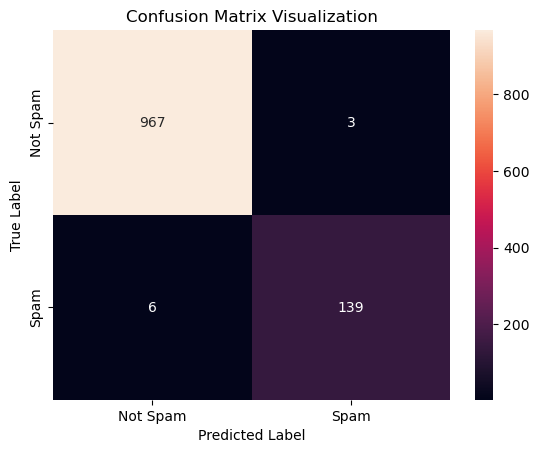

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from matplotlib import pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Visualization')
plt.show()

In [43]:
emails=[
    'Hello you job offer was ready',
    'You have 20% of discount for gold chain purchase',
    'you won a lottery of 1 lakhs with 100% offer'
]
emails_count=v.transform(emails)
model.predict(emails_count)

array(['ham', 'spam', 'spam'], dtype='<U4')

In [40]:
model.predict_proba(emails_count)

array([[9.99378011e-01, 6.21989250e-04],
       [3.93290470e-01, 6.06709530e-01],
       [6.13865650e-01, 3.86134350e-01]])